Data Collection

In [1]:
import pandas as pd

df_adult = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_adult.head()

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [2]:
df_youth = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_youth.head()

,entity,code,year,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,71.00000,42.00000,Asia
4,Afghanistan,AFG,2022,83.40000,44.17171,Asia


In [3]:
df_illiterate = pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_illiterate.head()

,entity,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [4]:
df_gdp = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_gdp.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [5]:
df_schooling = pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_schooling.head()


,entity,code,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia


Data Merge

In [6]:
df_literacy = pd.merge(df_adult, df_youth, on = ['entity', 'code', 'year'], how = 'inner')
df_literacy.head()

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe


In [7]:
df_gdp_schooling = pd.merge(df_gdp, df_schooling, on = ['entity', 'code', 'year'], how = 'inner')
df_gdp_schooling.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region_x,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region_y
0,Afghanistan,AFG,2000,1617.8264,Asia,NaN,3.03,20130334.0,Asia
1,Afghanistan,AFG,2005,1908.1147,Asia,NaN,3.32,24404575.0,Asia
2,Afghanistan,AFG,2010,2848.5862,Asia,NaN,3.93,28284088.0,Asia
3,Afghanistan,AFG,2011,2757.0525,Asia,31.00000,NaN,29347708.0,Asia
4,Afghanistan,AFG,2015,2967.6921,Asia,33.75384,4.81,33831767.0,Asia


Data Cleaning

In [8]:
df_literacy.isnull().sum()

entity                                                                         0
code                                                                         729
year                                                                           0
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99      0
youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m           0
youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f         0
owid_region                                                                  777
dtype: int64

In [9]:
#drop nulls
df_literacy = df_literacy.dropna()
df_literacy.isnull().sum()

entity                                                                       0
code                                                                         0
year                                                                         0
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99    0
youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m         0
youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f       0
owid_region                                                                  0
dtype: int64

In [10]:
df_literacy.duplicated().sum()

np.int64(0)

In [11]:
#rename columns
df_literacy = df_literacy.rename(columns={
    'entity': 'Country',
    'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99' : 'Adult_Literacy_Rate',
    'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m' : 'Youth_Literacy_Rate_Male',
    'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f' : 'Youth_Literacy_Rate_Female',
})
df_literacy.head()

,Country,code,year,Adult_Literacy_Rate,Youth_Literacy_Rate_Male,Youth_Literacy_Rate_Female,owid_region
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe


In [12]:
df_literacy['year'].unique()

array([1979, 2011, 2015, 2021, 2001, 2008, 2012, 2017, 1987, 2002, 2006,
       1980, 2014, 1984, 1991, 1989, 2016, 2020, 2022, 2000, 2010, 1999,
       2007, 2009, 2013, 2019, 2023, 1981, 2018, 1970, 1992, 2005, 1976,
       2003, 2004, 1975, 1996, 1990, 1998, 1988, 1993, 1982, 1986, 1994,
       1983, 1985, 1995, 1977, 1997, 1978])

In [13]:
#filter years from 1990 to 2023
df_literacy = df_literacy[(df_literacy['year'] >= 1990) & (df_literacy['year'] <= 2023)]
df_literacy['year'].unique()

array([2011, 2015, 2021, 2001, 2008, 2012, 2017, 2002, 2006, 2014, 1991,
       2016, 2020, 2022, 2000, 2010, 1999, 2007, 2009, 2013, 2019, 2023,
       2018, 1992, 2005, 2003, 2004, 1996, 1990, 1998, 1993, 1994, 1995,
       1997])

In [14]:
df_illiterate.isnull().sum()

entity               0
code               733
year                 0
illiteracy_rate      0
literacy_rate        0
dtype: int64

In [15]:
#drop nulls
df_illiterate = df_illiterate.dropna()
df_illiterate.isnull().sum()

entity             0
code               0
year               0
illiteracy_rate    0
literacy_rate      0
dtype: int64

In [16]:
df_illiterate.duplicated().sum()

np.int64(0)

In [17]:
#rename columns
df_illiterate = df_illiterate.rename(columns={'entity': 'Country'})
df_illiterate.head()

,Country,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [18]:
df_illiterate['year'].unique()

array([1950, 1979, 2011, 2015, 2021, 2001, 2008, 2012, 2017, 1987, 2002,
       2006, 1980, 2014, 1984, 1914, 1947, 1991, 1989, 2016, 2020, 2022,
       2000, 2010, 1999, 2007, 2009, 2013, 2019, 2023, 1981, 2018, 1970,
       1475, 1550, 1650, 1750, 1900, 1910, 1920, 1930, 1992, 2005, 1976,
       2003, 1940, 2004, 1905, 1926, 1934, 1975, 1996, 1990, 1998, 1901,
       1911, 1921, 1931, 1988, 1993, 1907, 1982, 1918, 1928, 1938, 1899,
       1919, 1943, 1917, 1927, 1937, 1986, 1994, 1906, 1936, 1946, 1935,
       1945, 1941, 1983, 1985, 1995, 1977, 1997, 1939, 1948, 1978, 1820,
       1870, 1880, 1890, 1960])

In [19]:
#filter years from 1990 to 2023
df_illiterate = df_illiterate[(df_illiterate['year'] >= 1990) & (df_illiterate['year'] <= 2023)]
df_illiterate['year'].unique()

array([2011, 2015, 2021, 2001, 2008, 2012, 2017, 2002, 2006, 2014, 1991,
       2016, 2020, 2022, 2000, 2010, 1999, 2007, 2009, 2013, 2019, 2023,
       2018, 1992, 2005, 2003, 2004, 1996, 1990, 1998, 1993, 1994, 1995,
       1997])

In [20]:
#rename columns
df_gdp_schooling = df_gdp_schooling.rename(columns={
    'entity': 'Country',
    'ny_gdp_pcap_pp_kd' : 'gdp',
    'mf_youth_and_adults__15_64_years__average_years_of_education' : 'Average_Years_of_Education'
})
df_gdp_schooling.head()

,Country,code,year,gdp,owid_region_x,literacy_rate,Average_Years_of_Education,population_historical,owid_region_y
0,Afghanistan,AFG,2000,1617.8264,Asia,NaN,3.03,20130334.0,Asia
1,Afghanistan,AFG,2005,1908.1147,Asia,NaN,3.32,24404575.0,Asia
2,Afghanistan,AFG,2010,2848.5862,Asia,NaN,3.93,28284088.0,Asia
3,Afghanistan,AFG,2011,2757.0525,Asia,31.00000,NaN,29347708.0,Asia
4,Afghanistan,AFG,2015,2967.6921,Asia,33.75384,4.81,33831767.0,Asia


In [21]:
df_gdp_schooling.isnull().sum()

Country                         0
code                            0
year                            0
gdp                             0
owid_region_x                   0
literacy_rate                 678
Average_Years_of_Education    683
population_historical           0
owid_region_y                   0
dtype: int64

In [22]:
#drop nulls
df_gdp_schooling = df_gdp_schooling.dropna()
df_gdp_schooling.isnull().sum()

Country                       0
code                          0
year                          0
gdp                           0
owid_region_x                 0
literacy_rate                 0
Average_Years_of_Education    0
population_historical         0
owid_region_y                 0
dtype: int64

In [23]:
df_gdp_schooling.duplicated().sum()

np.int64(0)

In [24]:
df_gdp_schooling['year'].unique()

array([2015, 2020, 2000, 2010, 1990, 2005, 1995])

Feature Engineering

In [25]:
df_illiterate['Illiteracy_percentage'] = 100 - df_illiterate['literacy_rate']
df_illiterate.head()

,Country,code,year,illiteracy_rate,literacy_rate,Illiteracy_percentage
2,Afghanistan,AFG,2011,69.000000,31.00000,69.00000
3,Afghanistan,AFG,2015,66.246155,33.75384,66.24616
4,Afghanistan,AFG,2021,63.000000,37.00000,63.00000
6,Albania,ALB,2001,1.000000,99.00000,1.00000
7,Albania,ALB,2008,4.000000,96.00000,4.00000


In [26]:
df_literacy['Literacy_Gender_Gap'] = df_literacy['Youth_Literacy_Rate_Male'] - df_literacy['Youth_Literacy_Rate_Female']
df_literacy.head()

,Country,code,year,Adult_Literacy_Rate,Youth_Literacy_Rate_Male,Youth_Literacy_Rate_Female,owid_region,Literacy_Gender_Gap
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia,30.00000
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia,32.25089
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia,29.00000
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe,0.00000
5,Albania,ALB,2008,96.00000,99.00000,99.00000,Europe,0.00000


In [27]:
df_gdp_schooling['GDP_per_Schooling_Year'] = df_gdp_schooling['gdp'] / df_gdp_schooling['Average_Years_of_Education']
df_gdp_schooling.head()

,Country,code,year,gdp,owid_region_x,literacy_rate,Average_Years_of_Education,population_historical,owid_region_y,GDP_per_Schooling_Year
4,Afghanistan,AFG,2015,2967.6921,Asia,33.75384,4.81,33831767.0,Asia,616.983805
47,Armenia,ARM,2020,15052.9360,Asia,100.00000,10.54,2890893.0,Asia,1428.172296
95,Bangladesh,BGD,2015,5352.7114,Asia,65.00000,6.76,159383179.0,Asia,791.821213
100,Bangladesh,BGD,2020,7015.1978,Asia,75.00000,7.23,166298024.0,Asia,970.290152
126,Belize,BLZ,2015,12348.7950,North America,90.91604,10.56,356341.0,North America,1169.393466


In [28]:
df_gdp_schooling['Education_Index'] = df_gdp_schooling['literacy_rate'] + df_gdp_schooling['Average_Years_of_Education']/2
df_gdp_schooling.head()

,Country,code,year,gdp,owid_region_x,literacy_rate,Average_Years_of_Education,population_historical,owid_region_y,GDP_per_Schooling_Year,Education_Index
4,Afghanistan,AFG,2015,2967.6921,Asia,33.75384,4.81,33831767.0,Asia,616.983805,36.15884
47,Armenia,ARM,2020,15052.9360,Asia,100.00000,10.54,2890893.0,Asia,1428.172296,105.27000
95,Bangladesh,BGD,2015,5352.7114,Asia,65.00000,6.76,159383179.0,Asia,791.821213,68.38000
100,Bangladesh,BGD,2020,7015.1978,Asia,75.00000,7.23,166298024.0,Asia,970.290152,78.61500
126,Belize,BLZ,2015,12348.7950,North America,90.91604,10.56,356341.0,North America,1169.393466,96.19604


In [29]:
df_literacy['Youth_Literacy_Average'] = df_literacy['Youth_Literacy_Rate_Male'] + df_literacy['Youth_Literacy_Rate_Female'] / 2
df_literacy.head()

,Country,code,year,Adult_Literacy_Rate,Youth_Literacy_Rate_Male,Youth_Literacy_Rate_Female,owid_region,Literacy_Gender_Gap,Youth_Literacy_Average
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia,30.00000,78.00000
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia,32.25089,70.47713
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia,29.00000,92.00000
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe,0.00000,148.50000
5,Albania,ALB,2008,96.00000,99.00000,99.00000,Europe,0.00000,148.50000


In [30]:
df_literacy['Literacy_Growth_Rate'] = df_literacy['Adult_Literacy_Rate'].pct_change() * 100
df_literacy.head()

,Country,code,year,Adult_Literacy_Rate,Youth_Literacy_Rate_Male,Youth_Literacy_Rate_Female,owid_region,Literacy_Gender_Gap,Youth_Literacy_Average,Literacy_Growth_Rate
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia,30.00000,78.00000,NaN
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia,32.25089,70.47713,8.883355
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia,29.00000,92.00000,9.617158
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe,0.00000,148.50000,167.567568
5,Albania,ALB,2008,96.00000,99.00000,99.00000,Europe,0.00000,148.50000,-3.030303


In [31]:
df_literacy.isnull().sum()

Country                       0
code                          0
year                          0
Adult_Literacy_Rate           0
Youth_Literacy_Rate_Male      0
Youth_Literacy_Rate_Female    0
owid_region                   0
Literacy_Gender_Gap           0
Youth_Literacy_Average        0
Literacy_Growth_Rate          1
dtype: int64

In [32]:
df_literacy = df_literacy.dropna()
df_literacy.isnull().sum()

Country                       0
code                          0
year                          0
Adult_Literacy_Rate           0
Youth_Literacy_Rate_Male      0
Youth_Literacy_Rate_Female    0
owid_region                   0
Literacy_Gender_Gap           0
Youth_Literacy_Average        0
Literacy_Growth_Rate          0
dtype: int64

In [33]:
df_gdp_schooling.isnull().sum()

Country                       0
code                          0
year                          0
gdp                           0
owid_region_x                 0
literacy_rate                 0
Average_Years_of_Education    0
population_historical         0
owid_region_y                 0
GDP_per_Schooling_Year        0
Education_Index               0
dtype: int64

In [34]:
df_illiterate.isnull().sum()

Country                  0
code                     0
year                     0
illiteracy_rate          0
literacy_rate            0
Illiteracy_percentage    0
dtype: int64

EDA

In [35]:
#Univariate Analysis

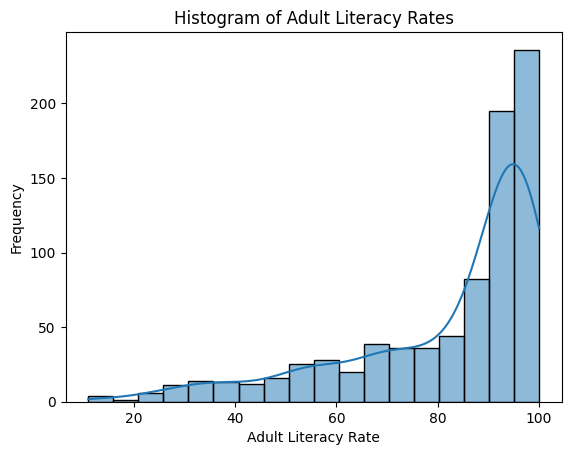

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_literacy['Adult_Literacy_Rate'], kde=True)
plt.title('Histogram of Adult Literacy Rates')   
plt.xlabel('Adult Literacy Rate')
plt.ylabel('Frequency')
plt.show()

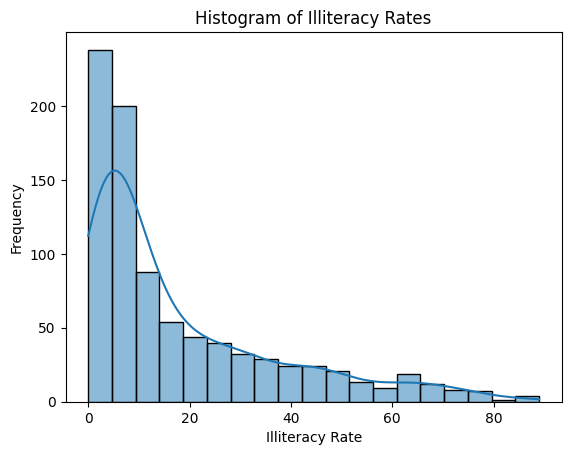

In [37]:
sns.histplot(df_illiterate['illiteracy_rate'], kde=True)
plt.title('Histogram of Illiteracy Rates')   
plt.xlabel('Illiteracy Rate')
plt.ylabel('Frequency')
plt.show()

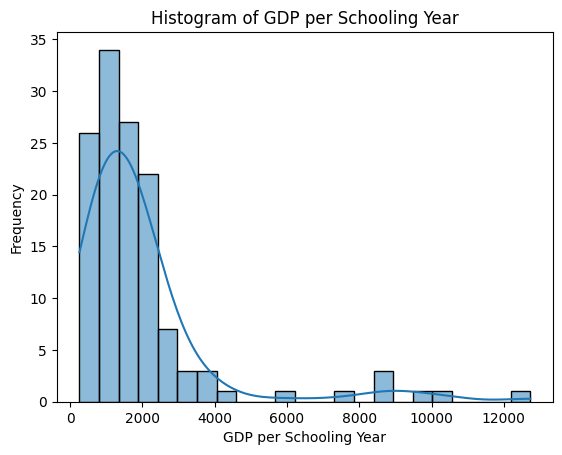

In [38]:
sns.histplot(df_gdp_schooling['GDP_per_Schooling_Year'], kde=True)
plt.title('Histogram of GDP per Schooling Year')   
plt.xlabel('GDP per Schooling Year')
plt.ylabel('Frequency')
plt.show()

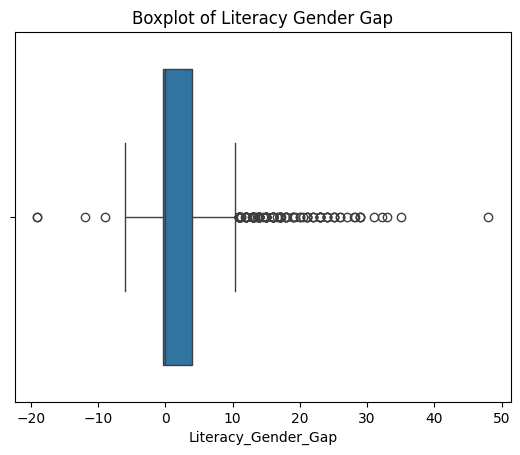

In [39]:
sns.boxplot(x=df_literacy['Literacy_Gender_Gap'])
plt.title("Boxplot of Literacy Gender Gap")
plt.show()

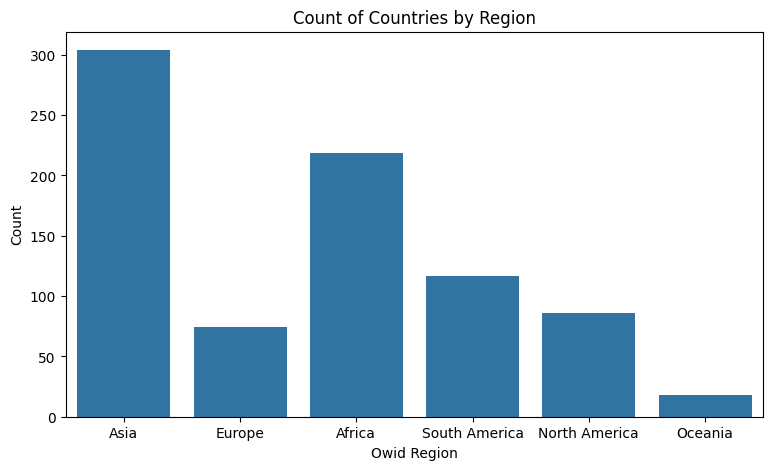

In [40]:
plt.figure(figsize=(9, 5))
sns.countplot(x= 'owid_region', data=df_literacy)
plt.title("Count of Countries by Region")
plt.xlabel("Owid Region")
plt.ylabel("Count")
plt.show()

In [41]:
#Bivariate Analysis

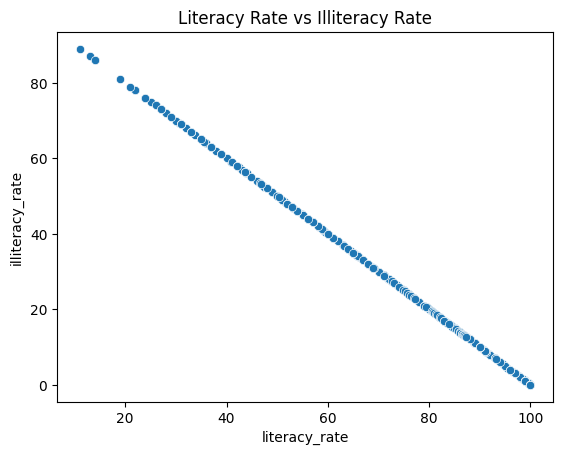

In [42]:
sns.scatterplot(x='literacy_rate', y='illiteracy_rate', data=df_illiterate)
plt.title("Literacy Rate vs Illiteracy Rate")
plt.show()

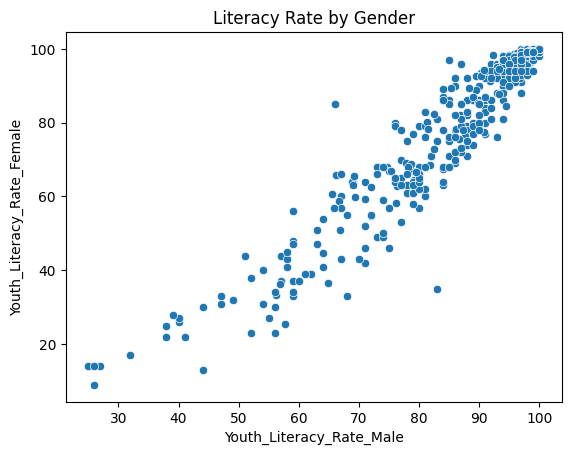

In [43]:
sns.scatterplot(x='Youth_Literacy_Rate_Male', y='Youth_Literacy_Rate_Female', data=df_literacy)
plt.title("Literacy Rate by Gender")
plt.show()

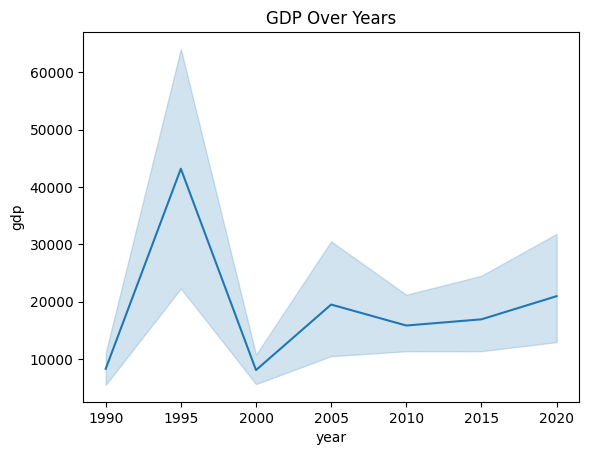

In [44]:
sns.lineplot(x='year', y='gdp', data=df_gdp_schooling)
plt.title("GDP Over Years")
plt.show()

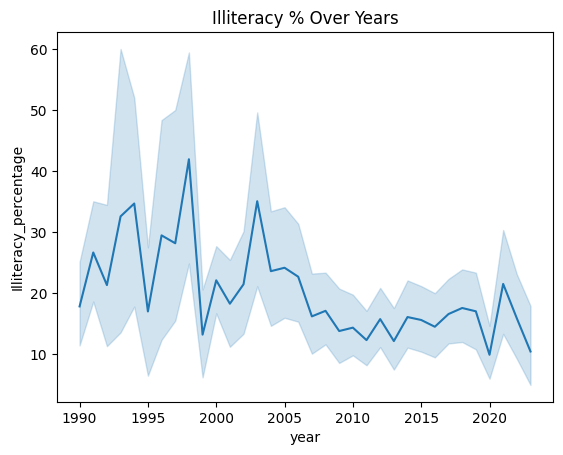

In [45]:
sns.lineplot(x='year', y='Illiteracy_percentage', data= df_illiterate)
plt.title("Illiteracy % Over Years")
plt.show()

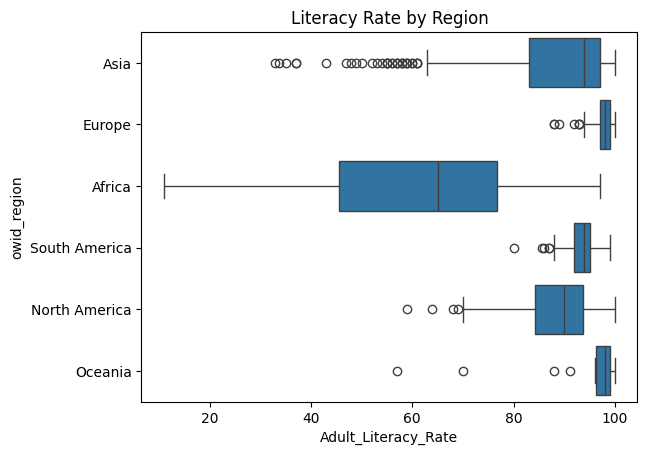

In [46]:
sns.boxplot(x='Adult_Literacy_Rate', y='owid_region', data=df_literacy)
plt.title("Literacy Rate by Region")
plt.show()

SQL Connection

In [47]:
pip install psycopg2-binary

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import psycopg2
import requests
secret = "Neha_jk200359"
DB_CONFIG = {
    "dbname": "global_literacy",
    "user": "postgres",
    "password": secret,
    "host": "localhost",
    "port": 5432
}

conn = psycopg2.connect(**DB_CONFIG)
cursor = conn.cursor()
print("Connected to DB")

Connected to DB


Tables creation

In [49]:
#literacy table

try:
    conn.rollback()
except Exception:
    # No active transaction to roll back
    pass

try:
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS literacy_rates (
        Country VARCHAR(300),
        code VARCHAR(10),
        year INT,
        Adult_Literacy_Rate FLOAT,
        Youth_Literacy_Rate_Male FLOAT,
        Youth_Literacy_Rate_Female FLOAT,
        owid_region VARCHAR(100),
        Literacy_Gender_Gap FLOAT,
        Youth_Literacy_Average FLOAT,
        Literacy_Growth_Rate FLOAT,
        PRIMARY KEY (Country, year)
    )
    """)
    conn.commit()
    print("Table created successfully")
except Exception as e:
    conn.rollback()
    print("Error creating table:", e)
    raise

Table created successfully


In [50]:
cursor = conn.cursor()
try:
    for index, row in df_literacy.iterrows():
        cursor.execute("""
        INSERT INTO literacy_rates (Country, code, year, Adult_Literacy_Rate, Youth_Literacy_Rate_Male, Youth_Literacy_Rate_Female, owid_region, Literacy_Gender_Gap, Youth_Literacy_Average, Literacy_Growth_Rate)
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        ON CONFLICT (Country, year) DO NOTHING
        """, (
            row['Country'],
            row['code'],
            row['year'],
            row['Adult_Literacy_Rate'],
            row['Youth_Literacy_Rate_Male'],
            row['Youth_Literacy_Rate_Female'],
            row['owid_region'],
            row['Literacy_Gender_Gap'],
            row['Youth_Literacy_Average'],
            row['Literacy_Growth_Rate']
        ))
    conn.commit()
except Exception as e:
    print(f"An error occurred: {e}")
    conn.rollback()
print("Data inserted successfully")

Data inserted successfully


In [51]:
#Illiteracy table

try:
    conn.rollback()
except Exception:
    # No active transaction to roll back
    pass

try:
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS illiteracy_population (
        Country VARCHAR(300),
        code VARCHAR(10),
        year INT,
        illiteracy_rate FLOAT,
        literacy_rate FLOAT,
        Illiteracy_percentage FLOAT,
        PRIMARY KEY (Country, year)
    )
    """)
    conn.commit()
    print("Table created successfully")
except Exception as e:
    conn.rollback()
    print("Error creating table:", e)
    raise


Table created successfully


In [52]:
cursor = conn.cursor()
try:
    for index, row in df_illiterate.iterrows():
        cursor.execute("""
        INSERT INTO illiteracy_population (Country, code, year, illiteracy_rate, literacy_rate, Illiteracy_percentage)
        VALUES (%s, %s, %s, %s, %s, %s)
        ON CONFLICT (Country, year) DO NOTHING
        """, (
            row['Country'],
            row['code'],
            row['year'],
            row['illiteracy_rate'],
            row['literacy_rate'],
            row['Illiteracy_percentage']
        ))
    conn.commit()
except Exception as e:
    print(f"An error occurred: {e}")
    conn.rollback()
print("Data inserted successfully")

Data inserted successfully


In [53]:
#Gdp_schooling table

try:
    conn.rollback()
except Exception:
    # No active transaction to roll back
    pass

try:
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS gdp_schooling (
        Country VARCHAR(300),
        code VARCHAR(10),
        year INT,
        gdp FLOAT,
        owid_region_x VARCHAR(100),
        literacy_rate FLOAT,
        Average_Years_of_Education FLOAT,
        population_historical FLOAT,
        owid_region_y VARCHAR(100),
        GDP_per_Schooling_Year FLOAT,
        Education_Index FLOAT,
        PRIMARY KEY (Country, year)
    )
    """)
    conn.commit()
    print("Table created successfully")
except Exception as e:
    conn.rollback()
    print("Error creating table:", e)
    raise

Table created successfully


In [54]:
cursor = conn.cursor()
try:
    for index, row in df_gdp_schooling.iterrows():
        cursor.execute("""
        INSERT INTO gdp_schooling(Country, code, year, gdp, owid_region_x, literacy_rate, Average_Years_of_Education, population_historical, owid_region_y, GDP_per_Schooling_Year, Education_Index)
        VALUES(%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        ON CONFLICT(Country, year) DO NOTHING
        """, (
            row['Country'],
            row['code'],
            row['year'],
            row['gdp'],
            row['owid_region_x'],
            row['literacy_rate'],
            row['Average_Years_of_Education'],
            row['population_historical'],
            row['owid_region_y'],
            row['GDP_per_Schooling_Year'],
            row['Education_Index']
        ))
    conn.commit()
except Exception as e:
    print(f"An error occurred: {e}")
    conn.rollback()
print("Data inserted successfully")

Data inserted successfully


SQL QUERIES

literacy_rates

In [55]:
#1. Get top 5 countries with highest adult literacy in 2020.

query = """
SELECT Country, Adult_Literacy_Rate
FROM literacy_rates
WHERE year = 2020
ORDER BY Adult_Literacy_Rate DESC
LIMIT 5
"""
pd.read_sql_query(query, conn)


C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\4098277796.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query(query, conn)


,country,adult_literacy_rate
0,Armenia,100.0
1,Mongolia,99.0
2,Spain,99.0
3,Philippines,98.0
4,Palestine,98.0


In [56]:
#2. Find countries where female youth literacy < 80%.

query = """
SELECT Country, Youth_Literacy_Rate_Female
FROM literacy_rates
WHERE Youth_Literacy_Rate_Female < 80
"""
pd.read_sql_query(query, conn)


C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\5664586.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query(query, conn)


,country,youth_literacy_rate_female
0,Afghanistan,25.48416
1,Afghanistan,42.00000
2,Angola,63.00000
3,Angola,71.00000
4,Angola,67.42760
...,...,...
169,Yemen,35.00000
170,Zambia,66.00000
171,Zambia,66.00000
172,Zambia,66.00000


In [57]:
#3. Average adult literacy per continent (owid region).

query = """
SELECT
    owid_region,
    Avg(Adult_Literacy_Rate) as Avg_Adult_literacy_rate
    FROM literacy_rates
    GROUP BY owid_region
    ORDER BY Avg_Adult_literacy_rate DESC;
"""
pd.read_sql(query, conn)



C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\2804179612.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,owid_region,avg_adult_literacy_rate
0,Europe,97.396630
1,South America,93.466994
2,Oceania,93.445866
3,North America,87.986129
4,Asia,87.331203
5,Africa,60.913878


illiteracy_population

In [58]:
#4. Countries with illiteracy % > 20% in 2000.

query = """
SELECT year, Country, Illiteracy_percentage
FROM illiteracy_population
WHERE year = 2000
AND Illiteracy_percentage > 20
ORDER BY Illiteracy_percentage DESC;
"""
pd.read_sql(query, conn)

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\2298878166.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,year,country,illiteracy_percentage
0,2000,Chad,74.0
1,2000,Gambia,63.0
2,2000,Guinea-Bissau,59.0
3,2000,Cote d'Ivoire,51.0
4,2000,Mauritania,49.0
5,2000,Central African Republic,49.0
6,2000,Togo,47.0
7,2000,Papua New Guinea,43.0
8,2000,Ghana,42.0
9,2000,Burundi,41.0


In [59]:
#5. Trend of illiteracy % for India (2000–2020).

query = """
SELECT Country, year, Illiteracy_percentage
FROM illiteracy_population
WHERE Country = 'India'
AND year BETWEEN 2000 AND 2020
ORDER BY year ASC;
"""
pd.read_sql(query, conn)

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\3812395414.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,country,year,illiteracy_percentage
0,India,2001,39.0
1,India,2006,37.0
2,India,2011,31.0


In [ ]:
#6. Top 10 countries with largest illiterate population in the last year.

query = """
SELECT Country, year, illiteracy_percentage
FROM illiteracy_population
WHERE year = (SELECT MAX(year) FROM illiteracy_population)
ORDER BY illiteracy_percentage DESC
LIMIT 9;
"""
pd.read_sql(query, conn)

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\1172358541.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,country,year,illiteracy_percentage
0,Senegal,2023,49.64418
1,India,2023,18.00000
2,Tunisia,2023,13.75318
3,World,2023,12.64397
4,Vanuatu,2023,12.03968
5,El Salvador,2023,10.00000
6,Sri Lanka,2023,7.00000
7,Jordan,2023,5.00000
8,Nauru,2023,3.41346
9,United Arab Emirates,2023,2.00000


gdp_schooling

In [61]:
#7. Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000.

query = """
SELECT Country, Average_Years_of_Education, gdp
FROM gdp_schooling
WHERE Average_Years_of_Education > 7
AND gdp < 5000;
"""
pd.read_sql(query, conn)

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\3820651652.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,country,average_years_of_education,gdp
0,China,7.79,4066.0364
1,Ghana,7.66,4495.6890
2,Philippines,7.15,4504.4624
3,Philippines,7.96,4740.4390
4,Zambia,7.40,3266.5076


In [62]:
#8. Rank countries by GDP per schooling for the year 2020.

query = """
SELECT 
    RANK() OVER (ORDER BY GDP_per_Schooling_Year DESC) AS rank,
    Country, 
    year, 
    GDP_per_Schooling_Year
FROM gdp_schooling
WHERE year = 2020
ORDER BY GDP_per_Schooling_Year DESC;
"""
df = pd.read_sql(query, conn)
print(df.to_string(index=False))

 rank      country  year  gdp_per_schooling_year
    1    Singapore  2020             8873.892802
    2       Kuwait  2020             7458.129909
    3 Saudi Arabia  2020             5823.603854
    4        Spain  2020             3610.204170
    5       Guyana  2020             2257.526995
    6        China  2020             2137.391991
    7       Mexico  2020             1937.964833
    8     Paraguay  2020             1697.809740
    9     Colombia  2020             1555.049020
   10     Mongolia  2020             1480.134200
   11      Armenia  2020             1428.172296
   12      Ecuador  2020             1371.590518
   13    Indonesia  2020             1367.389073
   14         Peru  2020             1366.425703
   15    Sri Lanka  2020             1344.303098
   16  El Salvador  2020             1196.598642
   17      Bolivia  2020             1135.282450
   18   Mauritania  2020             1074.456829
   19   Bangladesh  2020              970.290152
   20  Philippines  

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\737471845.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [63]:
#9. Find global average schooling years per year.

query = """
SELECT 
    year,
    AVG(Average_Years_of_Education) as global_average_schooling_years
FROM gdp_schooling
GROUP BY year
ORDER BY year;
"""
pd.read_sql(query, conn)

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\3870045754.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,year,global_average_schooling_years
0,1990,6.583000
1,1995,8.105000
2,2000,6.237000
3,2005,7.559286
4,2010,8.166071
5,2015,7.665588
6,2020,8.738261


Join Queries

In [64]:
#10. List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling(less than 6).

query = """
SELECT Country, year, gdp, Average_Years_of_Education
FROM gdp_schooling
WHERE year = 2020
AND Average_Years_of_Education < 6
ORDER BY gdp DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\1666394583.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,country,year,gdp,average_years_of_education
0,Mauritania,2020,5963.2354,5.55
1,Rwanda,2020,2520.3174,5.24
2,Malawi,2020,1656.4398,5.41
3,Mozambique,2020,1466.1248,4.22


In [65]:
#11. Show countries where the illiterate population is high despite having more than 10 average years of schooling.

query = """
SELECT
    i.Country,
    i.illiteracy_percentage AS illiterate_population,
    g.Average_Years_of_Education AS average_years_of_education
FROM illiteracy_population i
JOIN gdp_schooling g
    ON i.Country = g.Country 
WHERE g.Average_Years_of_Education > 10
ORDER BY  i.illiteracy_percentage DESC;
"""
pd.read_sql(query, conn)

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\3281808905.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,country,illiterate_population,average_years_of_education
0,Belize,30.0,10.56
1,South Africa,18.0,10.15
2,Malaysia,17.0,10.89
3,South Africa,13.0,10.15
4,Malta,12.0,10.06
...,...,...,...
193,Russia,0.0,12.02
194,Russia,0.0,12.02
195,Armenia,0.0,10.54
196,Armenia,0.0,10.54


In [87]:
#12. Compare literacy rates and GDP per capita growth for a selected country over the last 20 years. (country of your choice)
query = """
SELECT
    i.Country,
    i.literacy_rate,
    g.year,
    g.gdp
FROM illiteracy_population i
LEFT JOIN gdp_schooling g
    ON i.Country = g.Country 
    AND i.year = g.year
WHERE i.Country = 'Mexico'
AND g.year >= (SELECT MAX(year) - 20 FROM illiteracy_population)
ORDER BY i.year ASC;
"""
pd.read_sql(query, conn)

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\700263751.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,country,literacy_rate,year,gdp
0,Mexico,92.0,2005,20277.256
1,Mexico,93.0,2010,20058.385
2,Mexico,94.0,2015,21408.928
3,Mexico,95.0,2020,19728.482


In [89]:
#13. Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000 in 2020.
query = """
SELECT
    l.Country,
    l.year,
    (Youth_Literacy_Rate_Male - Youth_Literacy_Rate_Female) AS Youth_literacy_diff,
    g.gdp
FROM literacy_rates l
LEFT JOIN gdp_schooling g
    ON l.Country = g.Country 
    AND l.year = g.year
WHERE g.gdp > 30000
AND l.year = 2020
ORDER BY Youth_literacy_diff DESC;
"""
pd.read_sql(query, conn)

C:\Users\neha2\AppData\Local\Temp\ipykernel_6324\3869070324.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(query, conn)


,country,year,youth_literacy_diff,gdp
0,Saudi Arabia,2020,1.0,57420.734
1,Singapore,2020,0.0,115893.040
2,Kuwait,2020,-1.0,49372.820
3,Spain,2020,-1.0,41553.450
